# Supervised Learning Course Assignment 2

| Name | ID |
|------|----|
|  Mohamed Beshr Al Sofi | 20230717  |


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':      120,
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


## Task2 -> build model

### part A

In [7]:
from numpy import pad
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense

models = []
for i in range(1,4):
    model = Sequential([
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')
    ])

    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val))
    models.append(model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,055,698 (4.03 MB)

 Trainable params: 1,055,698 (4.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 24)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,185,634 (12.15 MB)

 Trainable params: 3,185,634 (12.15 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3561 - loss: 2.7402 - val_accuracy: 0.4731 - val_loss: 1.4505
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5188 - loss: 1.3438 - val_accuracy: 0.5080 - val_loss: 1.3891
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6020 - loss: 1.1238 - val_accuracy: 0.5267 - val_loss: 1.3744
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6709 - loss: 0.9325 - val_accuracy: 0.5183 - val_loss: 1.4736
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7164 - loss: 0.8023 - val_accuracy: 0.5177 - val_loss: 1.5710
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7627 - loss: 0.6746 - val_accuracy: 0.5042 - val_loss: 1.8569
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7949 - loss: 0.5901 - val_accuracy: 0.5145 - val_loss: 1.9113
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8396 - loss: 0.4630 - val

In [9]:
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

accuracy_scores = []
name_models = ['model1','model2','model3']
for i,model in enumerate(models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


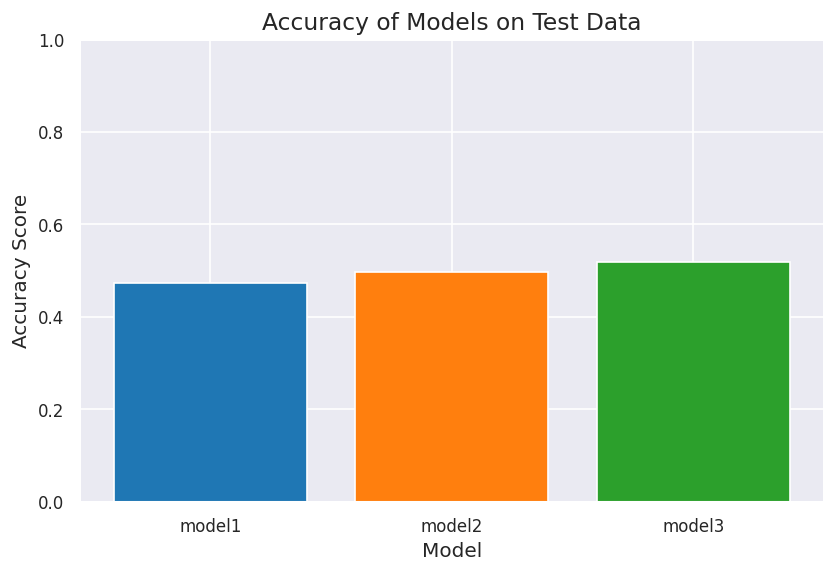

In [10]:
# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.show()

### Part C

In [11]:
from tensorflow.keras.layers import GlobalAveragePooling2D
models = [
    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')])
    ]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
history = []
for i,model in enumerate(models):
    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    history.append(model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val)))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,128,618 (8.12 MB)

 Trainable params: 2,128,618 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.3369 - loss: 1.7727 - val_accuracy: 0.4276 - val_loss: 1.5393
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4832 - loss: 1.4051 - val_accuracy: 0.5423 - val_loss: 1.2596
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5738 - loss: 1.1826 - val_accuracy: 0.5913 - val_loss: 1.1295
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6271 - loss: 1.0402 - val_accuracy: 0.6296 - val_loss: 1.0266
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6607 - loss: 0.9520 - val_accuracy: 0.6659 - val_loss: 0.9475
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6966 - loss: 0.8576 - val_accuracy: 0.6785 - val_loss: 0.9303
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7161 - loss: 0.8015 - val_accuracy: 0.6930 - val_loss: 0.8865
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7328 - loss: 0.7570 - va

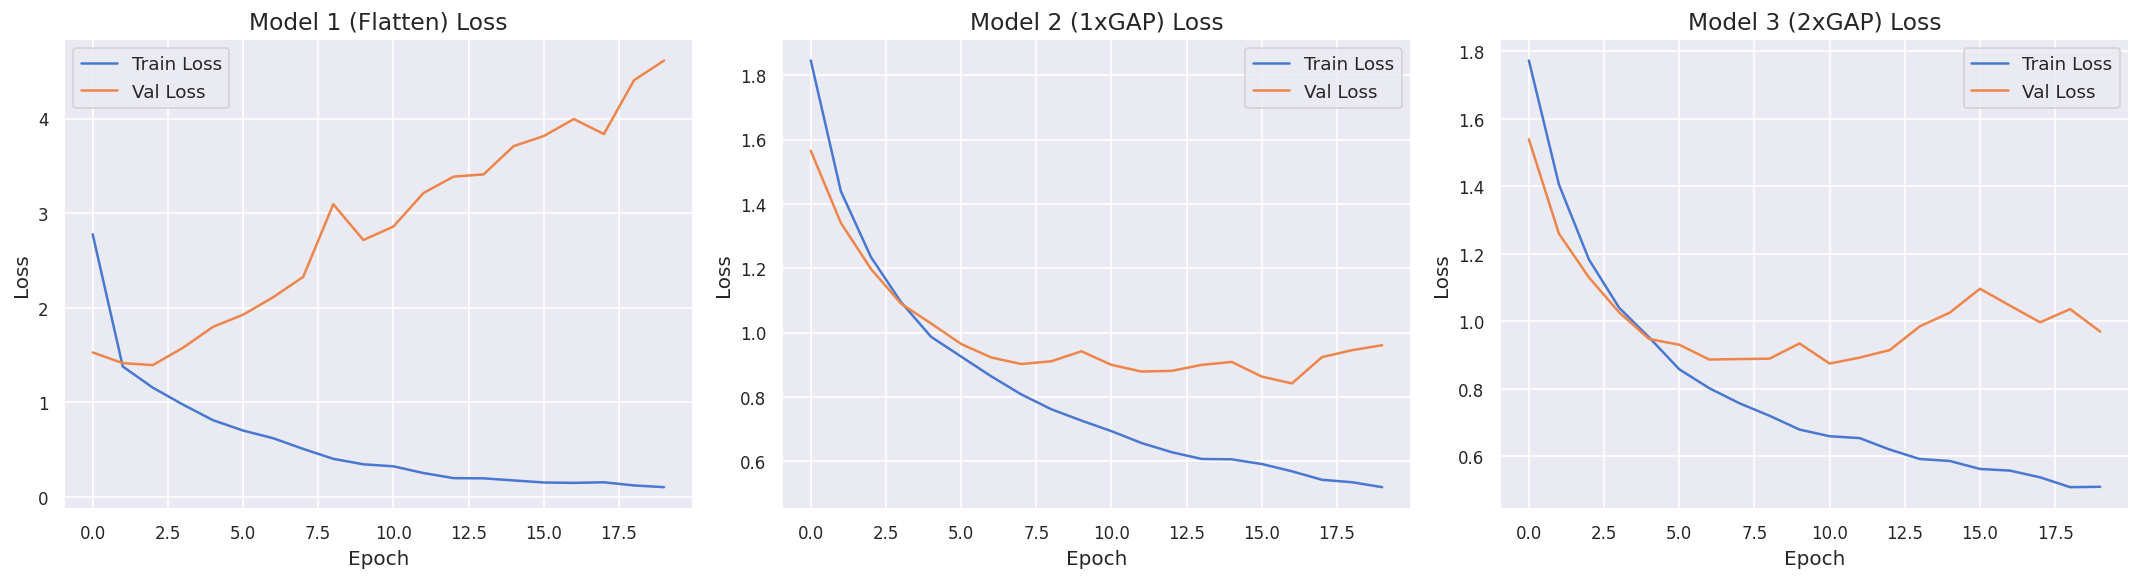

In [20]:
# Depth loss Comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
model_names = ['Model 1 (Flatten)', 'Model 2 (1xGAP)', 'Model 3 (2xGAP)']

for i, h in enumerate(history):
    axs[i].plot(h.history['loss'], label='Train Loss')
    axs[i].plot(h.history['val_loss'], label='Val Loss')
    axs[i].set_title(f'{model_names[i]} Loss')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Loss')
    axs[i].legend()

plt.tight_layout()
plt.show()

In [21]:
# accuracy
accuracy_scores = []
for i,model in enumerate(models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


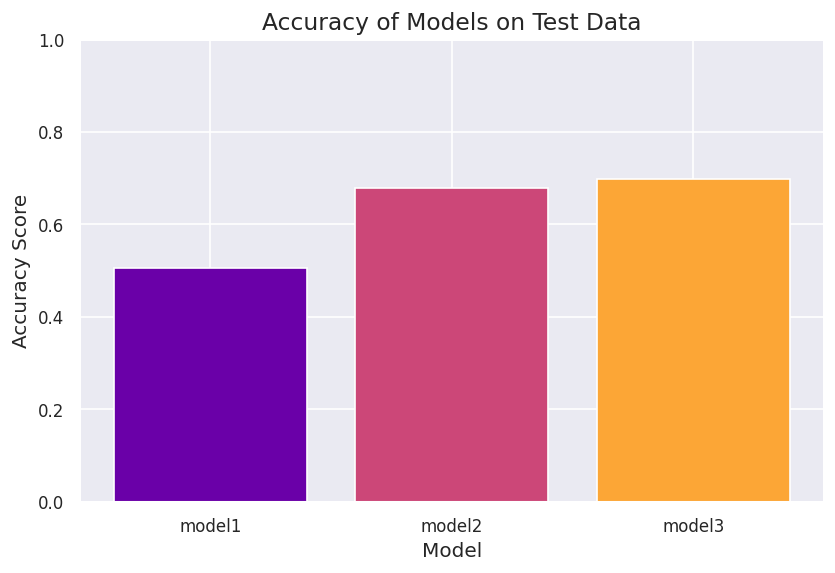

In [25]:
# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(name_models))))
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()